In [1]:
from torch import nn, optim, torch
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import sys
import os
sys.path.append(os.path.abspath(".."))

%load_ext autoreload
%autoreload 2
from src.features import pull_features_per_subject


In [22]:
# clean data
df = pd.read_csv("../data/intermediate/pamap_cleaned_df.csv")
X, y, subjects = pull_features_per_subject(df, nn=True) # nn = True to extract flattened raw data for neural network input

In [23]:
print(X.shape)  # Should be (sample_idx, num_samples, num_features)

(689, 500, 39)


## Set Up CNN and Dataset Objects

In [24]:
class PAMAPDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [25]:
class ActivityCNN(nn.Module):
    def __init__(self, n_channels, n_classes):
        super().__init__()

        self.conv1 = nn.Conv1d(in_channels=n_channels, out_channels=64, kernel_size=7, padding=3)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(128, n_classes)
    
    def forward(self, x):
        x = x.transpose(1, 2)  # Reshape to (batch_size, n_channels, sequence_length)
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)
        x = x.squeeze(-1)
        return self.fc(x)

In [26]:
CNN_model = ActivityCNN(n_channels=39, n_classes=12)

In [27]:
# encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y)
num_classes = len(le.classes_)

In [28]:
# perform train-val split on baseline model
X_train, X_val, y_train, y_val = train_test_split(
    X, y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc
)

In [29]:
train_loader = DataLoader(
    PAMAPDataset(X_train, y_train),
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    PAMAPDataset(X_val, y_val),
    batch_size=32
)

In [30]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = ActivityCNN(n_channels=39, n_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [31]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=10):

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):

        # ---- Training ----
        model.train()

        running_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        # ---- Validation ----
        model.eval()

        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)

                val_loss += loss.item()

                preds = outputs.argmax(dim=1)

                correct += (preds == y_batch).sum().item()
                total += y_batch.size(0)

        val_loss /= len(val_loader)
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch + 1:02d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    return history

### CNN + LSTM

In [32]:
class CNNLSTM(nn.Module):
    def __init__(self, n_channels, n_classes, hidden_size=128, lstm_layers=1):
        super().__init__()
        self.conv1 = nn.Conv1d(n_channels, 64, kernel_size=7, padding=3)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5,padding=2)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.lstm = nn.LSTM(input_size=128, hidden_size=hidden_size, num_layers=lstm_layers, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, n_classes)

    def forward(self, x):
        # x = (batch, 500, 39)
        x = x.transpose(1, 2)
        # (batch, 39, 500)
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        # (batch, 128, reduced_time)
        x = x.transpose(1, 2)
        # (batch, reduced_time, 128)
        lstm_out, (h_n, c_n) = self.lstm(x)
        x = h_n[-1]
        x = self.dropout(x)
        return self.fc(x)

## Evaluate

In [41]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()
CNN_model = ActivityCNN(n_channels=39, n_classes=num_classes).to(device)
optimizer = optim.Adam(CNN_model.parameters(), lr=1e-3)

CNN_model_results = train_model(model=CNN_model, 
                                train_loader=train_loader,
                                val_loader=val_loader, 
                                criterion=criterion, 
                                optimizer=optimizer, 
                                device=device, 
                                epochs=10)

Epoch 01 | Train Loss: 1.7950 | Val Loss: 1.0544 | Val Acc: 0.6667
Epoch 02 | Train Loss: 0.9144 | Val Loss: 0.8591 | Val Acc: 0.7174
Epoch 03 | Train Loss: 0.6939 | Val Loss: 0.6134 | Val Acc: 0.8116
Epoch 04 | Train Loss: 0.4635 | Val Loss: 0.4932 | Val Acc: 0.8188
Epoch 05 | Train Loss: 0.3206 | Val Loss: 0.3446 | Val Acc: 0.8841
Epoch 06 | Train Loss: 0.2569 | Val Loss: 0.3319 | Val Acc: 0.9058
Epoch 07 | Train Loss: 0.1831 | Val Loss: 0.2397 | Val Acc: 0.9203
Epoch 08 | Train Loss: 0.1916 | Val Loss: 0.2524 | Val Acc: 0.9420
Epoch 09 | Train Loss: 0.1412 | Val Loss: 0.2193 | Val Acc: 0.9493
Epoch 10 | Train Loss: 0.1759 | Val Loss: 0.2834 | Val Acc: 0.9058


In [42]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()
CNN_LSTM_model = CNNLSTM(n_channels=39, n_classes=num_classes).to(device)
optimizer = optim.Adam(CNN_LSTM_model.parameters(), lr=1e-3)

CNN_LSTM_model_results = train_model(model=CNN_LSTM_model, 
                                train_loader=train_loader,
                                val_loader=val_loader, 
                                criterion=criterion, 
                                optimizer=optimizer, 
                                device=device, 
                                epochs=10)

Epoch 01 | Train Loss: 2.2108 | Val Loss: 1.9587 | Val Acc: 0.4493
Epoch 02 | Train Loss: 1.7989 | Val Loss: 1.6541 | Val Acc: 0.4565
Epoch 03 | Train Loss: 1.6570 | Val Loss: 1.6072 | Val Acc: 0.5145
Epoch 04 | Train Loss: 1.5068 | Val Loss: 1.4745 | Val Acc: 0.5000
Epoch 05 | Train Loss: 1.3152 | Val Loss: 1.2124 | Val Acc: 0.6377
Epoch 06 | Train Loss: 1.1685 | Val Loss: 1.2218 | Val Acc: 0.5797
Epoch 07 | Train Loss: 1.2792 | Val Loss: 1.2678 | Val Acc: 0.6739
Epoch 08 | Train Loss: 1.1876 | Val Loss: 1.3120 | Val Acc: 0.5217
Epoch 09 | Train Loss: 1.2718 | Val Loss: 1.1869 | Val Acc: 0.5435
Epoch 10 | Train Loss: 1.1731 | Val Loss: 1.0813 | Val Acc: 0.6884


## Save CNN

In [43]:
# Save CNN
torch.save(
    CNN_model.state_dict(),
    "../models/cnn_baseline.pth"
)

In [44]:
cnn_model = ActivityCNN(
    n_channels=39,
    n_classes=num_classes
).to(device)

cnn_model.load_state_dict(
    torch.load(
        "../models/cnn_baseline.pth",
        weights_only=True
    )
)

cnn_model.eval()

ActivityCNN(
  (conv1): Conv1d(39, 64, kernel_size=(7,), stride=(1,), padding=(3,))
  (conv2): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (pool): AdaptiveAvgPool1d(output_size=1)
  (fc): Linear(in_features=128, out_features=12, bias=True)
)

In [45]:
y_true = []
y_pred = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:

        X_batch = X_batch.to(device)

        outputs = cnn_model(X_batch)
        preds = outputs.argmax(dim=1)

        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

In [47]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

cnn_accuracy = accuracy_score(y_true, y_pred)

cnn_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

print(f"CNN Accuracy: {cnn_accuracy:.4f}")
print(f"CNN Macro F1: {cnn_f1:.4f}")

CNN Accuracy: 0.9058
CNN Macro F1: 0.8804


In [50]:
import matplotlib.pyplot as plt
import src.features as features


def plot_confusion_matrix_with_accuracy_score(y_true, y_pred, model_name, encoder):
    labels = np.unique(np.concatenate([y_true, y_pred]))

    cm = confusion_matrix(y_true, y_pred,labels=labels)

    # Convert encoded labels to PAMAP activity IDs
    original_labels = encoder.inverse_transform(labels)

    display_labels = [features.ACTIVITY_LABEL_MAP[int(label)] for label in original_labels]

    accuracy = accuracy_score(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(10, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(xticks_rotation=45, ax=ax, cmap=plt.cm.Blues)
    ax.set_title(f"LOSO Confusion Matrix — {model_name} " f"(Accuracy: {accuracy:.2%})")
    ax.set_xlabel("Predicted Activity")
    ax.set_ylabel("True Activity")
    plt.tight_layout()
    plt.savefig(f"../data/results/{model_name}_confusion_matrix.png")
    plt.show()

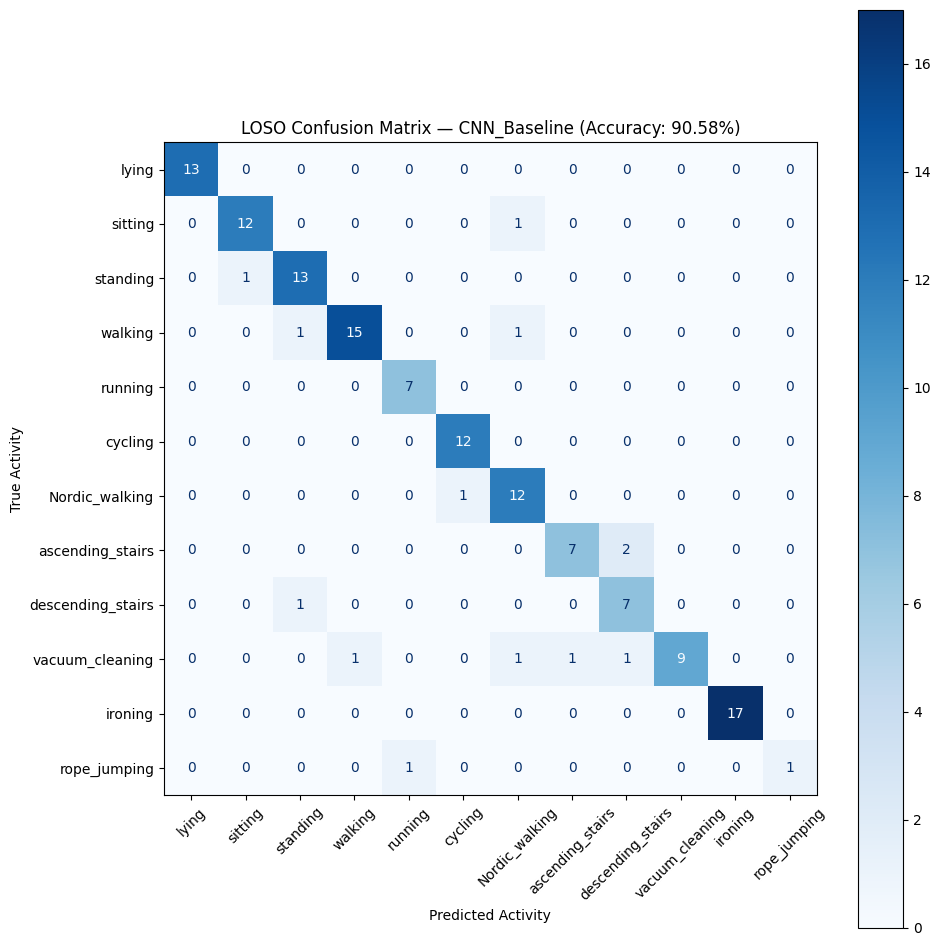

In [51]:
plot_confusion_matrix_with_accuracy_score(
        y_true,
        y_pred,
        model_name="CNN_Baseline",
        encoder=le
    )